In [ ]:
# Plots CDFs of RV and transiting planet occurrence rates

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
file_name = '/Users/eckhartspalding/Documents/git.repos/misc/notebooks_for_development/exoplanet_archive_2025.09.11_22.21.15.csv'

In [3]:
df = pd.read_csv(file_name, skiprows=291)

/var/folders/wb/zn41c4yx58z1ktmcwgv62zyr0000gn/T/ipykernel_77064/754338883.py:1: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_name, skiprows=291)


In [4]:
df

,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_id,default_flag,sy_snum,sy_pnum,...,rowupdate,pl_pubdate,releasedate,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec
0,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,1,2,1,...,2023-09-19,2023-08,2023-09-19,2,1,2,0,0,0,0
1,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,0,2,1,...,2014-07-23,2011-08,2014-07-23,2,1,2,0,0,0,0
2,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,0,2,1,...,2014-05-14,2008-01,2014-05-14,2,1,2,0,0,0,0
3,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,0,1,1,...,2018-04-25,2011-08,2014-07-23,0,1,1,0,0,0,0
4,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,0,1,1,...,2018-04-25,2009-10,2014-05-14,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38774,ups And d,ups And,d,HD 9826,HIP 7513,TIC 189576919,Gaia DR2 348020448377061376,0,2,3,...,2014-09-18,2007-01,2014-09-18,5,1,10,1,0,0,0
38775,ups Leo b,ups Leo,b,NaN,NaN,TIC 49430557,Gaia DR2 3794167001116433152,1,1,1,...,2022-01-10,2021-12,2022-01-10,0,0,0,0,0,0,0
38776,xi Aql b,xi Aql,b,HD 188310,HIP 97938,TIC 375464367,Gaia DR2 4298361114750843904,0,1,1,...,2014-07-23,2011-08,2014-07-23,1,1,1,0,0,0,0
38777,xi Aql b,xi Aql,b,HD 188310,HIP 97938,TIC 375464367,Gaia DR2 4298361114750843904,0,1,1,...,2014-05-14,2008-06,2014-05-14,1,1,1,0,0,0,0


In [8]:
len(df)

38779

In [9]:
df = df.drop_duplicates(subset=['pl_name'])

In [5]:
df_rv = df.loc[df['discoverymethod'] == 'Radial Velocity']
df_transit = df.loc[df['discoverymethod'] == 'Transit']

In [6]:
list(df.keys())

['pl_name',
 'hostname',
 'pl_letter',
 'hd_name',
 'hip_name',
 'tic_id',
 'gaia_id',
 'default_flag',
 'sy_snum',
 'sy_pnum',
 'sy_mnum',
 'cb_flag',
 'discoverymethod',
 'disc_year',
 'disc_refname',
 'disc_pubdate',
 'disc_locale',
 'disc_facility',
 'disc_telescope',
 'disc_instrument',
 'rv_flag',
 'pul_flag',
 'ptv_flag',
 'tran_flag',
 'ast_flag',
 'obm_flag',
 'micro_flag',
 'etv_flag',
 'ima_flag',
 'dkin_flag',
 'soltype',
 'pl_controv_flag',
 'pl_refname',
 'pl_orbper',
 'pl_orbpererr1',
 'pl_orbpererr2',
 'pl_orbperlim',
 'pl_orbsmax',
 'pl_orbsmaxerr1',
 'pl_orbsmaxerr2',
 'pl_orbsmaxlim',
 'pl_rade',
 'pl_radeerr1',
 'pl_radeerr2',
 'pl_radelim',
 'pl_radj',
 'pl_radjerr1',
 'pl_radjerr2',
 'pl_radjlim',
 'pl_masse',
 'pl_masseerr1',
 'pl_masseerr2',
 'pl_masselim',
 'pl_massj',
 'pl_massjerr1',
 'pl_massjerr2',
 'pl_massjlim',
 'pl_msinie',
 'pl_msinieerr1',
 'pl_msinieerr2',
 'pl_msinielim',
 'pl_msinij',
 'pl_msinijerr1',
 'pl_msinijerr2',
 'pl_msinijlim',
 'pl_cmasse

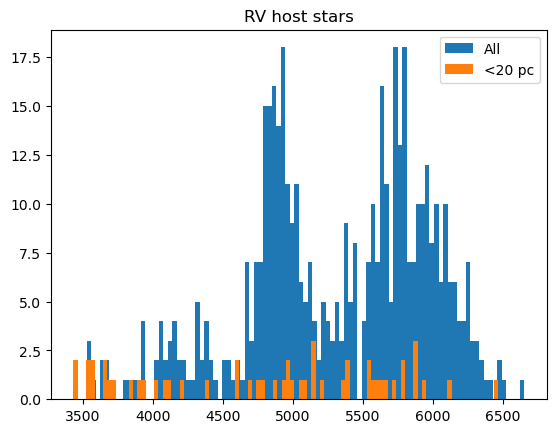

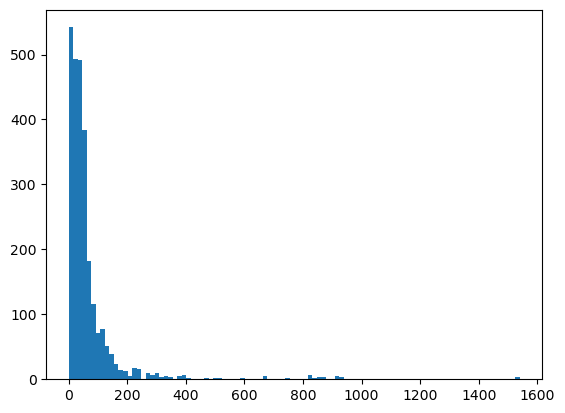

In [ ]:
df_rv_hosts_only = df_rv.drop_duplicates(subset=['hd_name'])

plt.clf()
plt.hist(df_rv_hosts_only['st_teff'], cumulative=False, bins=100, label='All')
plt.hist(df_rv_hosts_only.loc[df_rv_hosts_only['sy_dist'] < 20, 'st_teff'], cumulative=False, bins=100, label='<20 pc')
plt.xlabel('T_eff (K)')
plt.ylabel('Number')
plt.legend()
plt.title('RV host stars')
plt.show()

plt.clf()
plt.hist(df_rv['sy_dist'], cumulative=False, bins=100)
plt.show()

In [10]:
df_rv['st_spectype']

0        G8 III
1           NaN
2        G8 III
3           NaN
4        K4 III
          ...  
38774      F8 V
38775    G9 III
38776       NaN
38777       NaN
38778    K0 III
Name: st_spectype, Length: 2645, dtype: object

In [18]:
df['discoverymethod'][0]

'Radial Velocity'

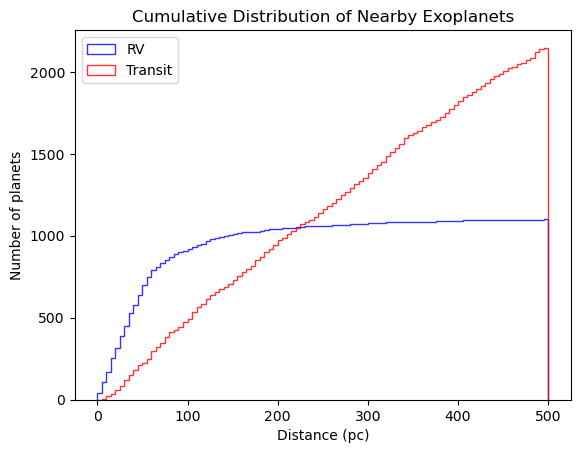

In [26]:
plt.hist(df_rv['sy_dist'], cumulative=True, bins=100, range=[0,500],
         histtype='step', alpha=0.8, color='blue', label='RV')
plt.hist(df_transit['sy_dist'], cumulative=True, bins=100, range=[0,500],
         histtype='step', alpha=0.8, color='red', label='Transit')
plt.ylabel('Number of planets')
plt.xlabel('Distance (pc)')
plt.title('Cumulative Distribution of Nearby Exoplanets')
plt.legend()
plt.savefig('junk.png', dpi=300)

In [27]:
file_name_2 = '/Users/eckhartspalding/Documents/git.repos/misc/notebooks_for_development/full_HPIC.txt'

In [30]:
df_hpic = pd.read_csv(file_name_2, delimiter='|')

In [34]:
list(df_hpic.keys())

['star_name',
 'ra',
 'dec',
 'ra_J2016',
 'dec_J2016',
 'tic_id',
 'gaia_dr2_id',
 'gaia_dr3_id',
 'hip_name',
 'tm_name',
 'tyc_name',
 'wds_designation',
 'simbad_name',
 'source_list_fl',
 'sy_pmra',
 'sy_pmraerr',
 'sy_pmdec',
 'sy_pmdecerr',
 'sy_pmsrc',
 'sy_pm_reflink',
 'sy_ujmag',
 'sy_ujmagerr',
 'sy_ujmagsrc',
 'sy_ujmag_reflink',
 'sy_bmag',
 'sy_bmagerr',
 'sy_bmagsrc',
 'sy_bmag_reflink',
 'sy_vmag',
 'sy_vmagerr',
 'sy_vmagsrc',
 'sy_vmag_reflink',
 'sy_rcmag',
 'sy_rcmagerr',
 'sy_rcmagsrc',
 'sy_rcmag_reflink',
 'sy_icmag',
 'sy_icmagerr',
 'sy_icmagsrc',
 'sy_icmag_reflink',
 'sy_jmag',
 'sy_jmagerr',
 'sy_jmagsrc',
 'sy_jmag_reflink',
 'sy_hmag',
 'sy_hmagerr',
 'sy_hmagsrc',
 'sy_hmag_reflink',
 'sy_kmag',
 'sy_kmagmerr',
 'sy_kmagsrc',
 'sy_kmag_reflink',
 'sy_tmag',
 'sy_tmagerr',
 'sy_gaiamag',
 'sy_gaiamagerr',
 'sy_gaiamagsrc',
 'sy_gaiamag_reflink',
 'sy_bpmag',
 'sy_bpmagerr',
 'sy_rpmag',
 'sy_rpmagerr',
 'sy_plx',
 'sy_plxerr',
 'sy_plxsrc',
 'sy_plx_refli

In [44]:
df_hpic['sy_dist'].sort_values().dropna()

3502      1.301911
7         1.347491
5         1.347491
2789      1.828106
12756     2.408358
           ...    
2667     49.992237
9410     49.992825
10774    49.995102
12496    49.996231
12615    49.998394
Name: sy_dist, Length: 12801, dtype: float64